## Setup

In [1]:
from IPython.display import Image, display
import sys
sys.path.insert(0, '/home/mohitm/DocForgeHub')

## 1. StateCase Agent

5-node LangGraph with tool-calling loop: load_mem → agent → conditional routing → tools → update_mem

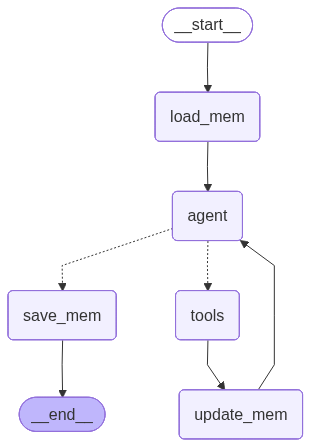

In [2]:
from rag.pipeline.statecase_agent_rag import _agent_graph

display(Image(_agent_graph.get_graph().draw_mermaid_png()))

## 2. RAG Agent (Corrective RAG)

5-node retrieval loop: retrieve → score → conditional routing → rewrite/done → pick_best
- Score ≥ 0.65: skip rewrite, return first-pass results
- Score < 0.65: rewrite query with Azure LLM + re-retrieve → compare and keep best

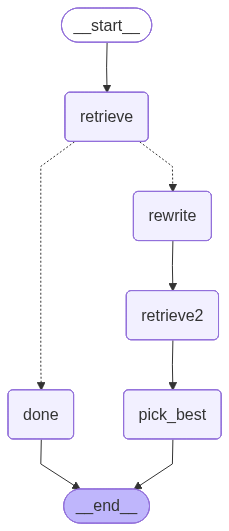

In [3]:
from rag.pipeline.corrective_rag_rag import _corrective_graph

display(Image(_corrective_graph.get_graph().draw_mermaid_png()))

## 3. DocForge Agent

5-node document generation: analyze_schema_gaps → build_prompt → generate_document → quality_gate → fix_document (with retry loop)

12:36:00  INFO      [agent.agent_graph]  🔨 Building document generation graph...
12:36:00  INFO      [agent.agent_graph]  ✅ Graph compiled — 5 nodes, entry=analyze_schema_gaps
12:36:00  INFO      [agent.agent_graph]  ✅ Section graph compiled — 4 nodes, no gap analysis, entry=build_prompt


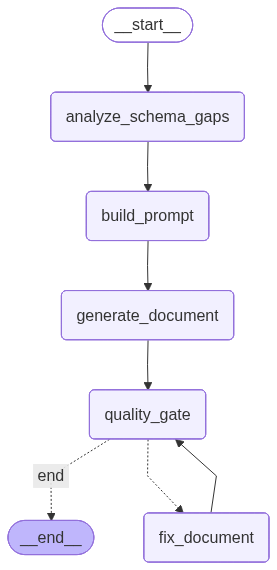

In [4]:
from agent.agent_graph import document_generation_agent

display(Image(document_generation_agent.get_graph().draw_mermaid_png()))